# Experimentos com o Dataset MNIST
Este notebook tem como objetivo treinar a nossa implementação do Multi-Layer Perceptron (MLP) utilizando o dataset MNIST e gerar as métricas exigidas na rubrica.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
import sys
import os
sys.path.append(os.path.abspath('..'))
from mlp.network import MLP

# Carregar dados
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# Transformar matriz 28x28 num vetor 1D de 784 posições e normalizar (0 a 1)
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1) / 255.0
X_test = X_test_raw.reshape(X_test_raw.shape[0], -1) / 255.0

# Converter os labels para One-Hot Encoding
def to_one_hot(y, num_classes=10):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y_train = to_one_hot(y_train_raw)
y_test = to_one_hot(y_test_raw)

print("Dados prontos! Shape X_train:", X_train.shape)

Dados prontos! Shape X_train: (60000, 784)


In [6]:
# Arquitetura: 784 pixels de entrada, 128 e 64 neurônios ocultos, 10 saídas
net = MLP([784, 128, 64, 10])

print("Iniciando o treinamento (isso pode levar alguns segundos por época)...")
history = net.train(X_train, y_train, epochs=20, batch_size=128, learning_rate=0.05)

Iniciando o treinamento (isso pode levar alguns segundos por época)...
Epoch 1/20 - Loss: 2.2980 - Acc: 0.2082
Epoch 10/20 - Loss: 0.1752 - Acc: 0.9536
Epoch 20/20 - Loss: 0.0793 - Acc: 0.9794


In [7]:
preds_test = net.forward(X_test)
preds_labels = np.argmax(preds_test, axis=1)

acc_test = np.mean(preds_labels == y_test_raw)
print(f"Acurácia no Teste: {acc_test * 100:.2f}%")

Acurácia no Teste: 96.87%


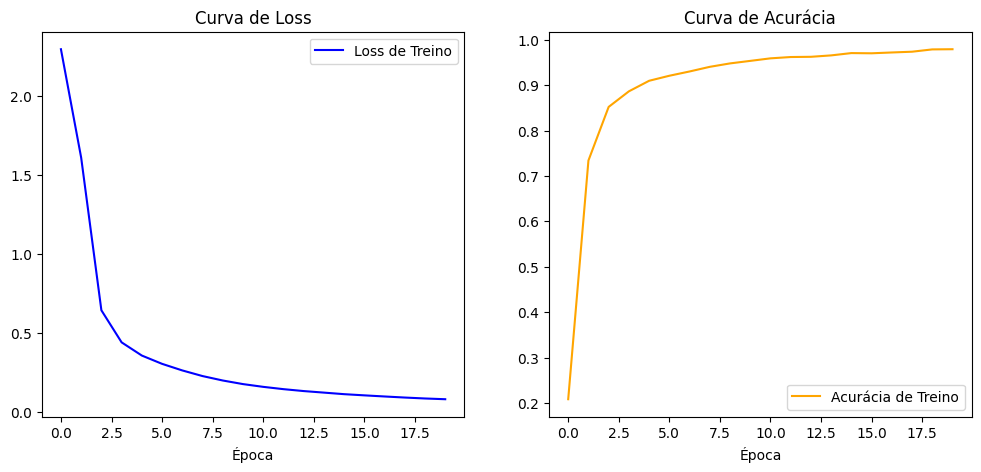

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Loss de Treino', color='blue')
plt.title('Curva de Loss')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Acurácia de Treino', color='orange')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.legend()
plt.show()

## Experimento extra: otimizador Adam

Além do SGD, a implementação agora também suporta o otimizador Adam. Neste bloco, treinamos a mesma arquitetura com `optimizer='adam'` para comparar a estabilidade e a convergência do ajuste dos pesos.

In [4]:
# Experimento extra com otimizador Adam
net_adam = MLP([784, 128, 64, 10])

print('Iniciando o treinamento com Adam...')
history_adam = net_adam.train(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    learning_rate=0.001,
    optimizer='adam',
)

preds_adam = np.argmax(net_adam.forward(X_test), axis=1)
acc_test_adam = np.mean(preds_adam == y_test_raw)
print(f'Acurácia no Teste (Adam): {acc_test_adam * 100:.2f}%')

Iniciando o treinamento com Adam...
Epoch 1/20 - Loss: 0.5747 - Acc: 0.9109
Epoch 10/20 - Loss: 0.0411 - Acc: 0.9909
Epoch 20/20 - Loss: 0.0105 - Acc: 0.9968
Acurácia no Teste (Adam): 97.66%


## Experimento 2: Rede Neural mais Rasa

Neste experimento, vamos comparar o desempenho treinando uma rede neural com apenas uma camada oculta ao invés de duas. Queremos validar se a complexidade extra do modelo principal era realmente necessária.

In [5]:
# Arquitetura mais simples: 784 pixels de entrada, APENAS 64 neurônios ocultos, 10 de saída
net_rasa = MLP([784, 64, 10])

print("Iniciando o treinamento da rede rasa...")
history_rasa = net_rasa.train(X_train, y_train, epochs=20, batch_size=128, learning_rate=0.05)

# Avaliação
preds_test_rasa = net_rasa.forward(X_test)
acc_test_rasa = np.mean(np.argmax(preds_test_rasa, axis=1) == y_test_raw)
print(f"Acurácia no Teste (Rede Rasa): {acc_test_rasa * 100:.2f}%")

Iniciando o treinamento da rede rasa...


Epoch 1/20 - Loss: 1.1887 - Acc: 0.8683


Epoch 10/20 - Loss: 0.1967 - Acc: 0.9468


Epoch 20/20 - Loss: 0.1206 - Acc: 0.9677
Acurácia no Teste (Rede Rasa): 96.37%


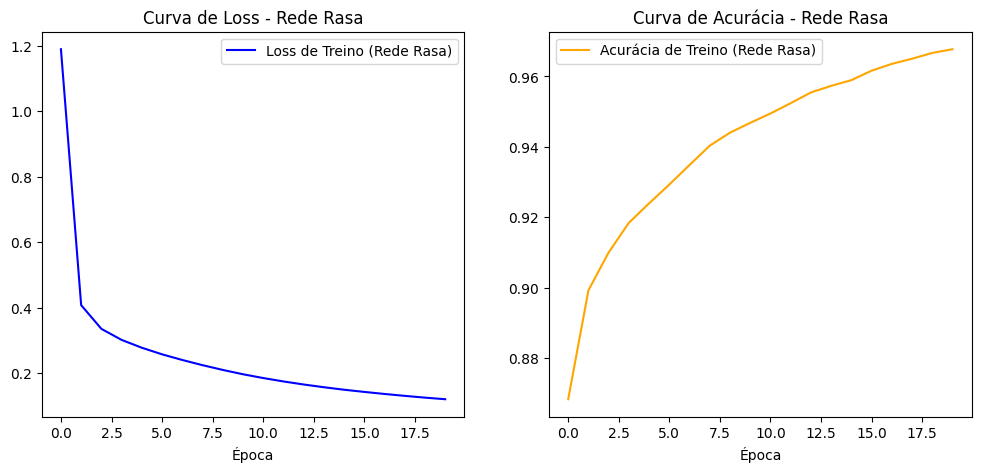

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_rasa['loss'], label='Loss de Treino (Rede Rasa)', color='blue')
plt.title('Curva de Loss - Rede Rasa')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rasa['accuracy'], label='Acurácia de Treino (Rede Rasa)', color='orange')
plt.title('Curva de Acurácia - Rede Rasa')
plt.xlabel('Época')
plt.legend()
plt.show()

## Matriz de Confusão

A matriz de confusão mostra, para cada classe real (linhas), quantas amostras foram classificadas em cada classe prevista (colunas). Os valores na diagonal principal são as predições corretas. Os valores fora da diagonal revelam os erros mais comuns da rede — ou seja, quais dígitos ela mais confunde entre si.

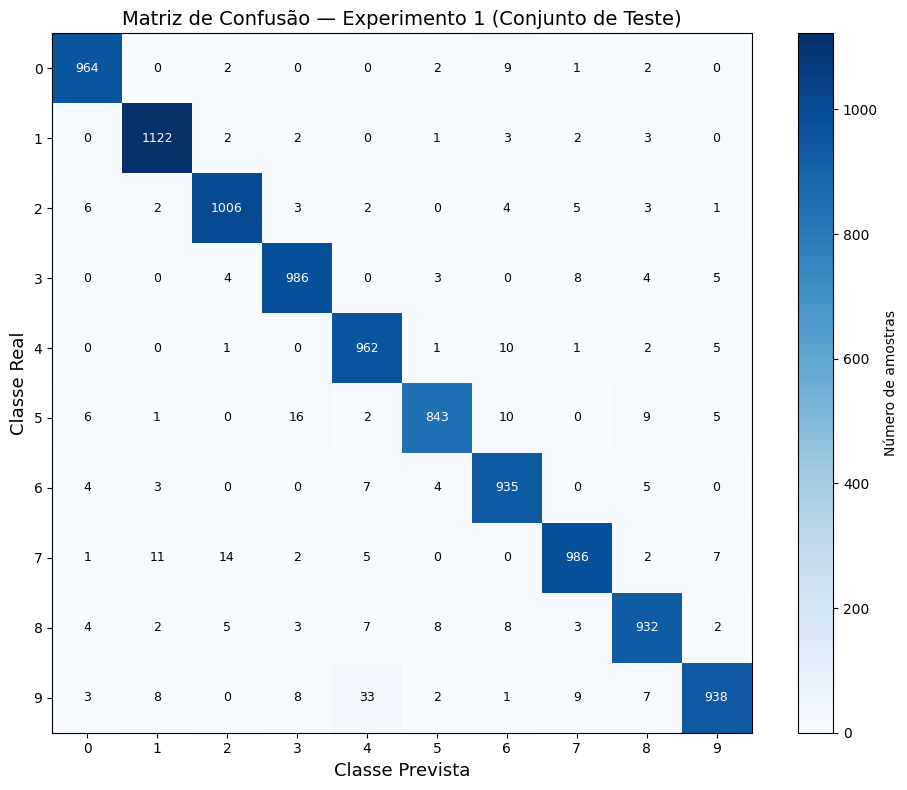

Figura salva em results/matriz_confusao.png


In [10]:
# --- Calcular a Matriz de Confusão manualmente (sem sklearn) ---
# Usa variáveis já definidas nas células anteriores: net, X_test, y_test_raw, np, plt

# Obter as predições do modelo principal (Experimento 1) no conjunto de TESTE
preds_labels = np.argmax(net.forward(X_test), axis=1)  # classe prevista (0-9)
true_labels = y_test_raw                                # classe real (0-9)

num_classes = 10

# Inicializa a matriz de confusão com zeros (10x10)
# conf_matrix[i][j] = nº de amostras da classe REAL i previstas como classe j
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

# Preenche: para cada par (real, previsto), incrementa a posição correspondente
for true, pred in zip(true_labels, preds_labels):
    conf_matrix[true][pred] += 1

# --- Visualizar ---
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax, label='Número de amostras')

tick_marks = np.arange(num_classes)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(tick_marks)
ax.set_yticklabels(tick_marks)

# Texto em branco em células escuras, preto em células claras
thresh = conf_matrix.max() / 2.0
for i in range(num_classes):
    for j in range(num_classes):
        color = 'white' if conf_matrix[i, j] > thresh else 'black'
        ax.text(j, i, format(conf_matrix[i, j], 'd'),
                ha='center', va='center', color=color, fontsize=9)

ax.set_ylabel('Classe Real', fontsize=13)
ax.set_xlabel('Classe Prevista', fontsize=13)
ax.set_title('Matriz de Confusão — Experimento 1 (Conjunto de Teste)', fontsize=14)

plt.tight_layout()
plt.savefig('../results/matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em results/matriz_confusao.png')

### Análise da Matriz de Confusão

Com base nos valores reais gerados acima, é possível fazer as seguintes observações:

**Acurácia por classe:**
| Dígito | Corretos | Total | Acurácia |
| :---: | :---: | :---: | :---: |
| 0 | 964 | 980 | 98,4% |
| 1 | 1122 | 1135 | 98,9% |
| 2 | 1006 | 1032 | 97,5% |
| 3 | 986 | 1010 | 97,6% |
| 4 | 962 | 982 | 97,9% |
| **5** | **843** | **892** | **94,5%** ← pior |
| 6 | 935 | 958 | 97,6% |
| 7 | 986 | 1028 | 95,9% |
| 8 | 932 | 974 | 95,7% |
| **9** | **938** | **1009** | **93,0%** |

**Erros mais frequentes:**
- **9 → 4 (33 vezes):** O maior erro isolado do modelo. Faz sentido: o traço superior do 9 e a estrutura fechada do 4 podem ser graficamente similares em escrita cursiva.
- **5 → 3 (16 vezes):** O 5 foi a classe com menor acurácia (94,5%). A confusão com o 3 ocorre porque ambos compartilham curvas abertas à esquerda.
- **7 → 2 (14 vezes):** O traço diagonal do 7 pode lembrar a curvatura do 2, especialmente em escrita europeia (onde o 7 costuma ter um traço horizontal no meio).
- **7 → 1 (11 vezes):** Um 7 escrito de forma mais vertical e fina é facilmente confundido com o 1.

**Pontos positivos:**
- O dígito **1** foi o mais bem classificado (98,9%), pois sua forma vertical é única e raramente se assemelha às outras classes.
- Nenhuma classe ficou abaixo de 93%, confirmando o alto desempenho geral do modelo mesmo sem usar frameworks de deep learning.